In [ ]:
import pandas as pd
import shutil
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
image_path = "./database/dataset/maligno/1-005_5.jpg"
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

In [ ]:
def img_compar(img_original, img_preprocess):
    '''
    Funcion utilizada para comparar la imagen antes y despues del procesmiento
    
    Parametros: 
    - img_original: imagen antes del procesamiento
    - img_preprocess: imagen procesada
    
    Output: La funcion muestra una figura de matplotlib con la imagen original y procesada
    '''
    # Mostrar la imagen original y la imagen preprocesada
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_original, cmap='gray')
    plt.title('Imagen Original')
    plt.axis('on')

    plt.subplot(1, 2, 2)
    plt.imshow(img_preprocess, cmap='gray')
    plt.title('Imagen Preprocesada')
    plt.axis('on')

    plt.show()

# Funciones para preprocesamiento de la imágen

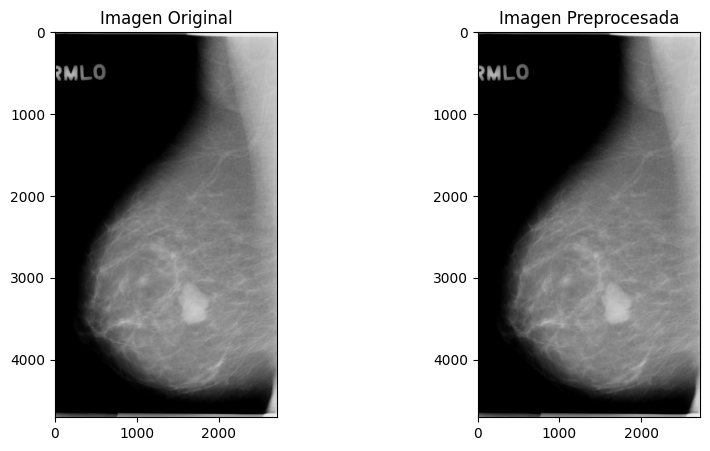

In [ ]:
def gaussian(img, gaussian_kernel_size=(3,3)):
    """
    Aplica un filtro gaussiano para suavizar una imagen y luego aplica un umbral binario.

    Parametros:
        img (numpy.ndarray): La imagen de entrada.
        gaussian_kernel_size (tuple, opcional): Tamaño del kernel gaussiano. Por defecto es (5, 5).
    Retorno:
        numpy.ndarray: La imagen con umbral binario aplicado.
    """
    
    # Aplicar un filtro gaussiano para suavizar la imagen
    #aqui CAMBIO EL FILTRO DE REDUCCION DE RUIDO
    blurred = cv2.GaussianBlur(img, gaussian_kernel_size, 0)
 
    return blurred

#Resultado de la imagen con filtro gaussiano aplicado
gaus = gaussian(img)

img_compar(img,gaus)
                                               

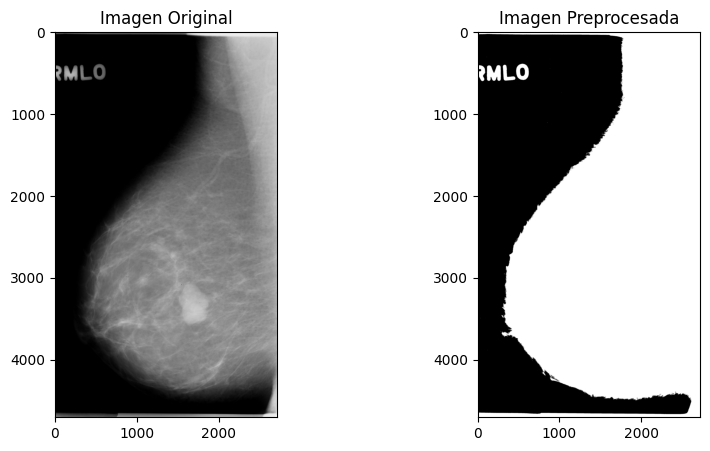

In [ ]:
def gaussian_and_tresholdA(img, gaussian_kernel_size=(3,3)):
    """
    Aplica un filtro gaussiano para suavizar una imagen y luego aplica un umbral binario.

    Parametros:
        img (numpy.ndarray): La imagen de entrada.
        gaussian_kernel_size (tuple, opcional): Tamaño del kernel gaussiano. Por defecto es (5, 5).
        
    Retorno:
        numpy.ndarray: La imagen con umbral binario aplicado.
    """
    
    # Aplicar un filtro gaussiano para suavizar la imagen
    blurred = cv2.GaussianBlur(img, gaussian_kernel_size, 0)

    # Aplicar umbralización  para resaltar las regiones de interés
    _,th1 = cv2.threshold(blurred,15,255,cv2.THRESH_BINARY)


    return th1
#Resultado de la máscara con filtro gaussiano aplicado y umbralizacion   
gaus_thres_img = gaussian_and_tresholdA(img)

img_compar(gaus,gaus_thres_img)
                                               

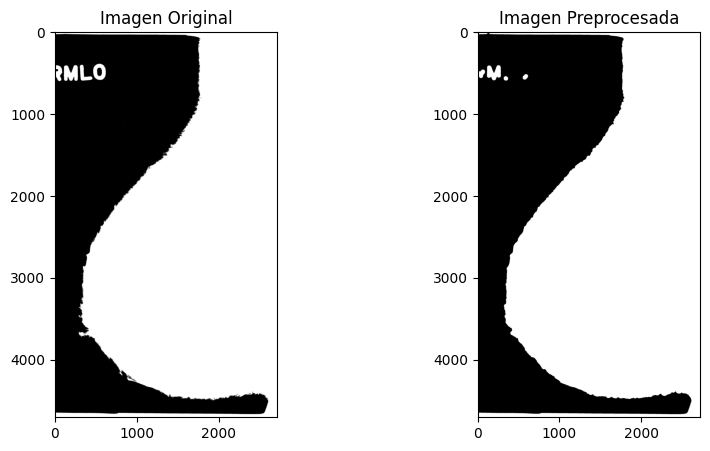

In [ ]:
def filter_morph_open(img,morph_kernel_size=(9,9)):
    
    """
    Aplica una operación morfológica para eliminar pequeños artefactos de una imagen.

    Args:
        img (numpy.ndarray): La imagen de entrada.
        morph_kernel_size (tuple, opcional): Tamaño del kernel morfológico. Por defecto es (30, 30).

    Returns:
        numpy.ndarray: La imagen con la operación morfológica aplicada.
    """

    # Aplicar operación morfológica para eliminar pequeños artefactos blancos
    morph_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, morph_kernel_size)
    
    morphed = cv2.morphologyEx(img, cv2.MORPH_OPEN, morph_kernel)

    return morphed

#Resultado de la máscara con operación morfológica aplicada
morphed_img = filter_morph_open(gaus_thres_img)

img_compar(gaus_thres_img,morphed_img)

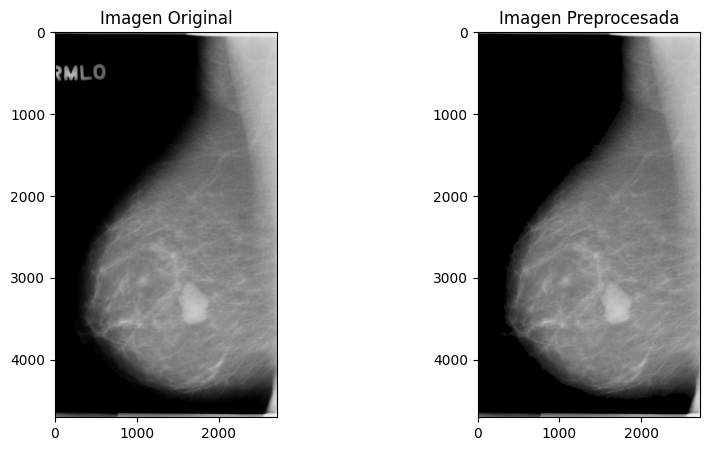

In [ ]:
def extract_largest_component(morphed,gaus_thres_img,original):
    
    """
    Encuentra el componente conectado más grande (asumido como el seno) en la imagen morfológicamente procesada 
    y lo extrae de la imagen original.

    Args:
        morphed (numpy.ndarray): Imagen procesada morfológicamente.
        gaus_thres_img (numpy.ndarray): Imagen con filtro haussiano y threshold.
        original (numpy.ndarray): Imagen original.

    Returns:
        numpy.ndarray: Imagen original con solo el componente más grande conservado.
    """
     # Encontrar todos los componentes conectados
    num_labels, labels_im = cv2.connectedComponents(morphed)

    #print("numero de componentes: ",num_labels)
    #print("labels img: ",labels_im)
    
    # Eliminar componentes conectados pequeños (asumimos que el seno es el componente más grande)
    unique, counts = np.unique(labels_im, return_counts=True)

    #print("unique components: ",unique)
    #print("counts : ",counts)
    #print("fondo: " ,counts[0])
    # Ignorar el fondo
    counts[0] = 0
    
    # Encontrar el componente más grande
    max_label = unique[np.argmax(counts)]

    #print("componente mas grande: ",max_label)
    
    # Crear una máscara solo con el componente más grande
    cleaned_background = np.zeros(gaus_thres_img.shape, np.uint8)

    cleaned_background[labels_im == max_label] = 255
    
    # Aplicar la máscara para mantener solo el objeto principal
    cleaned_image = cv2.bitwise_and(original, original, mask=cleaned_background)

    return cleaned_image

#Resultado de la imagen con filtro gaussiano aplicado y umbralizacion, 
# operación morfológica aplicada y extracción del componente más grande
nose_img = extract_largest_component(morphed_img,gaus_thres_img,gaus)


img_compar(img,nose_img)

In [ ]:
def filter_clahe(img):
    """
    Aplica el filtro de Adaptive Histogram Equalization (CLAHE) a una imagen para mejorar el contraste.

    Parameters:
    img (numpy.ndarray): Imagen en escala de grises a la cual se aplicará el filtro CLAHE. 
                         La imagen debe estar en formato de matriz bidimensional (grayscale).

    Returns:
    numpy.ndarray: Imagen procesada después de aplicar CLAHE, con un mejor contraste.
    """
    if img.dtype != np.uint8:
        img = (img * 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(12,12))
    final_image = clahe.apply(img)
    return final_image
clahe_img = filter_clahe(nose_img)

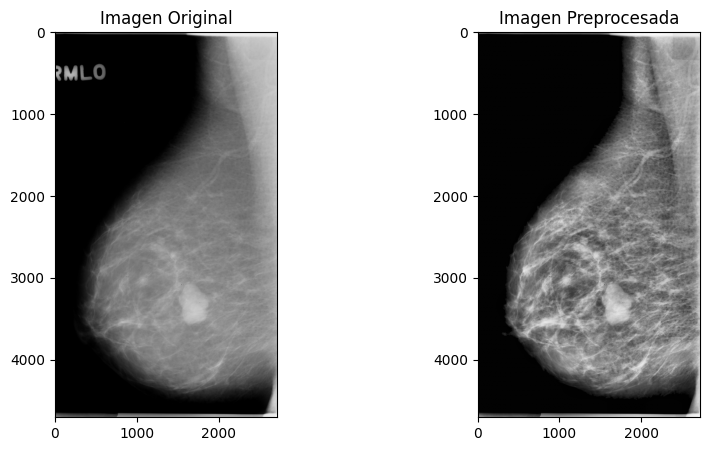

In [ ]:

img_compar(img,clahe_img)

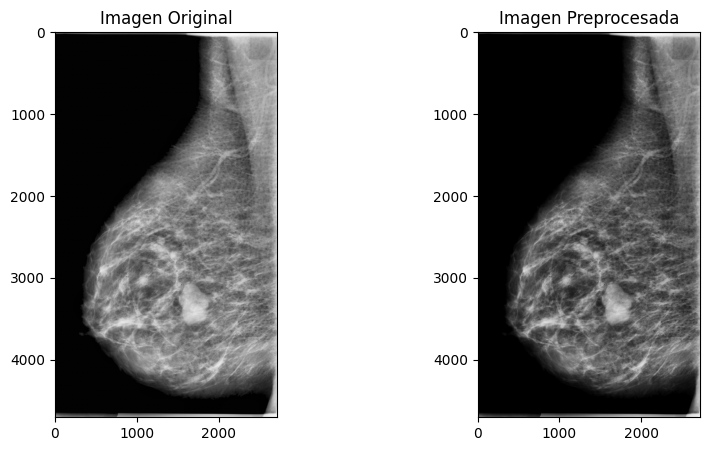

In [ ]:
def gammaFilter(img):
    gamma = 1.5
    img_gamma = np.power(img/255,gamma) *255.0
    img_gamma = img_gamma.astype(np.uint8)
    return img_gamma

gamma = gammaFilter(clahe_img)   
img_compar(clahe_img,gamma)

In [ ]:
imgs[0]

array([[149, 148, 149, ..., 235, 232, 255],
       [108, 108, 108, ..., 235, 236, 235],
       [  0,   0,   0, ..., 219, 219, 222],
       ...,
       [  0,   0,   0, ...,  59,  65,  83],
       [  3,   1,   0, ..., 217, 215, 236],
       [137, 139, 134, ..., 234, 237, 253]], dtype=uint8)

# Pipeline procesamiento

In [ ]:
def images_processor(imgs):
    imgs_processor = []
    for img in imgs:
       
        gaussian_img = gaussian(img)
        threshold_mask = gaussian_and_tresholdA(gaussian_img)
        morphology = filter_morph_open(threshold_mask)
        cleaned_img = extract_largest_component(morphology,threshold_mask,gaussian_img)
        clahe_img = filter_clahe(cleaned_img)
        gamma_img = gammaFilter(clahe_img)

        normalized_img = (gamma_img / 255.0).astype(np.float32)
        imgs_processor.append(normalized_img)

    
    return np.array(imgs_processor)

In [ ]:
imgs_processor = images_processor(imgs)

In [ ]:
imgs_processor[2]

array([[0.01568628, 0.01568628, 0.01568628, ..., 1.        , 1.        ,
        1.        ],
       [0.01568628, 0.01568628, 0.01568628, ..., 1.        , 1.        ,
        1.        ],
       [0.01568628, 0.01568628, 0.01568628, ..., 0.88235295, 1.        ,
        1.        ],
       ...,
       [0.01568628, 0.01568628, 0.01568628, ..., 1.        , 1.        ,
        1.        ],
       [0.01568628, 0.01568628, 0.01568628, ..., 1.        , 1.        ,
        1.        ],
       [0.01568628, 0.01568628, 0.01568628, ..., 1.        , 1.        ,
        1.        ]], dtype=float32)

In [ ]:
imgs_processor[0].shape

(224, 224)

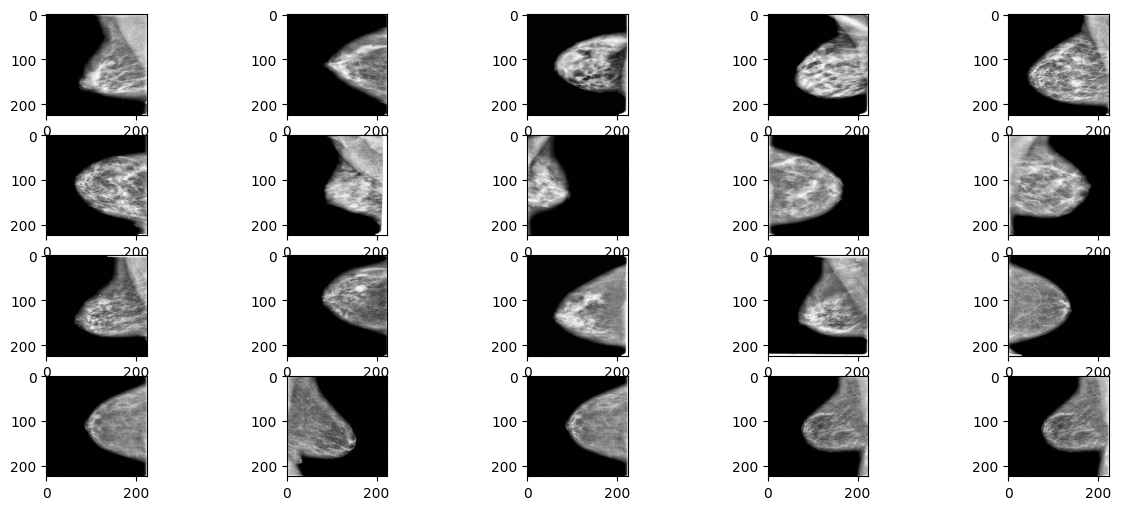

In [ ]:
show_imgs(imgs_processor)